## Импорт библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torchinfo import summary
import numpy as np

## Используем доступное устройство: GPU(CUDA), если видеокарта - NVIDIA, иначе - CPU

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

device: cuda


## Предварительно загружаем данные, чтобы посмотреть на них

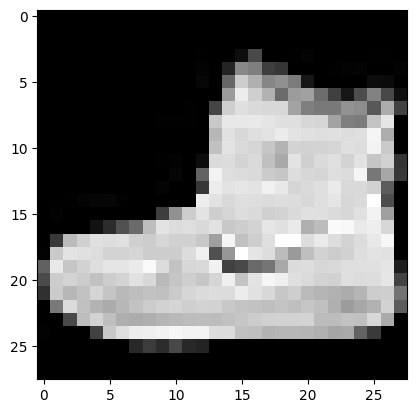

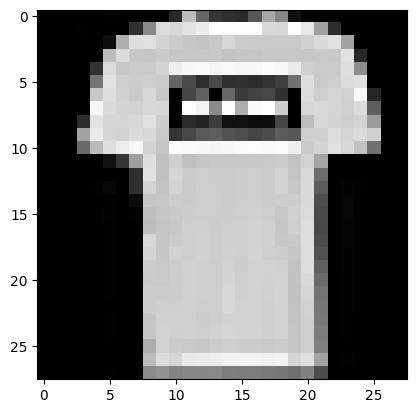

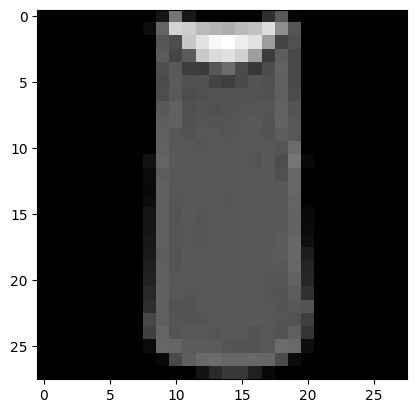

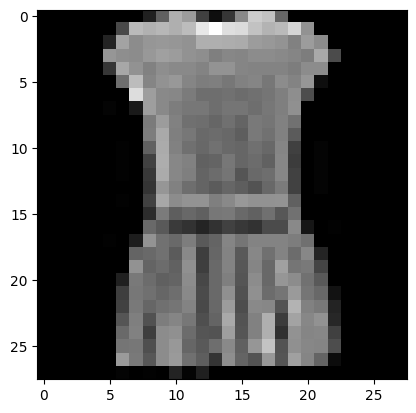

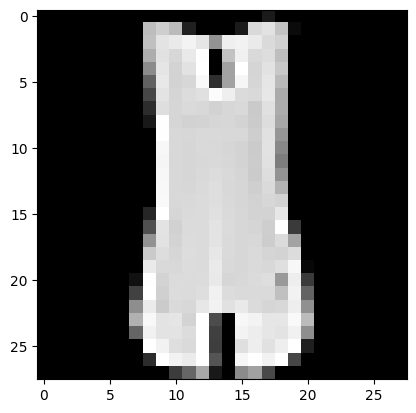

In [3]:
train_data = torchvision.datasets.FashionMNIST(root='fashion_mnist',download=True,train=True)

for i in range(5):
    plt.imshow(train_data[i][0], cmap='gray')
    plt.show()

## Загружаем данные, делим трейн на трейн и валидацию, используем Dataloader, чтобы подавать данные батчами + используем трансформер для превращения данных в тензоры с последующей нормализацией + выполняем аугментацию

In [4]:
TRAIN_SIZE = 50000
VALIDATION_SIZE = 10000
BATCH_SIZE = 128

full_train_dataset = torchvision.datasets.FashionMNIST(root='fashion_mnist', train=True, download=True)
test_dataset_raw = torchvision.datasets.FashionMNIST(root='fashion_mnist', train=False, download=True)

train_subset, val_subset = random_split(full_train_dataset, [TRAIN_SIZE, VALIDATION_SIZE])

# Считаем статистики только на трейне после сплита на трейн/вал, чтобы избежать утечки данных
train_data_pixels = full_train_dataset.data[train_subset.indices].float() / 255.0
mean, std = train_data_pixels.mean().item(), train_data_pixels.std().item()

# Пишем два различных трансформера для трейна и теста/вала
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),                   
    transforms.RandomRotation(degrees=15),                    
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), 
    transforms.ToTensor(),                                    
    transforms.Normalize((mean,), (std,))                   
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Применяем наши трансформеры
train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, val_test_transform)
test_dataset = TransformSubset(test_dataset_raw, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
print(f"Кол-во батчей на трейне: {len(train_loader)}")
print(f"Кол-во батчей на валидации: {len(val_loader)}")
print(f"Кол-во батчей на тесте: {len(test_loader)}")

Кол-во батчей на трейне: 391
Кол-во батчей на валидации: 79
Кол-во батчей на тесте: 79


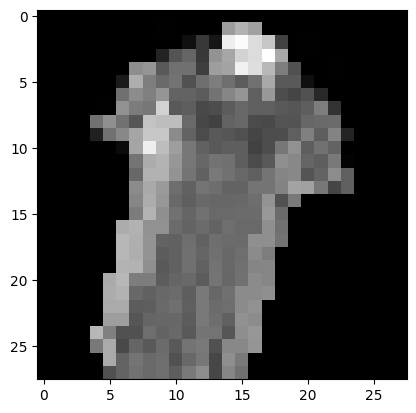

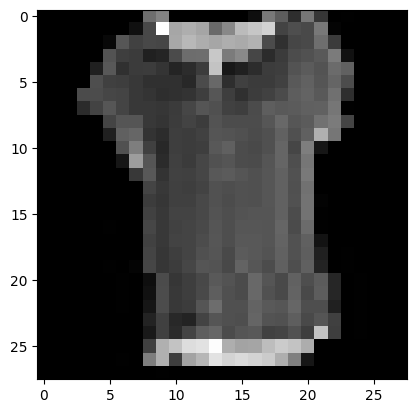

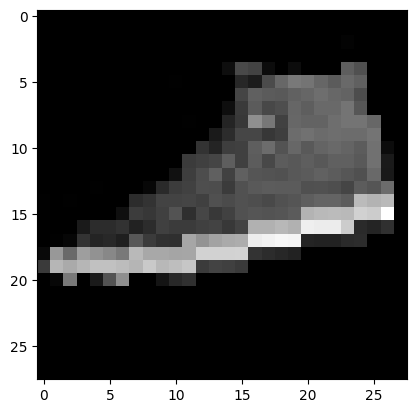

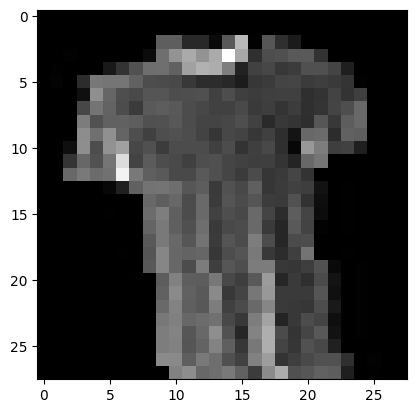

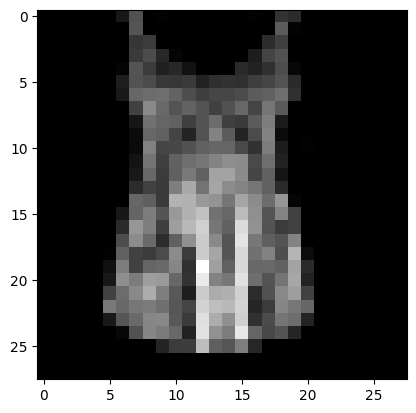

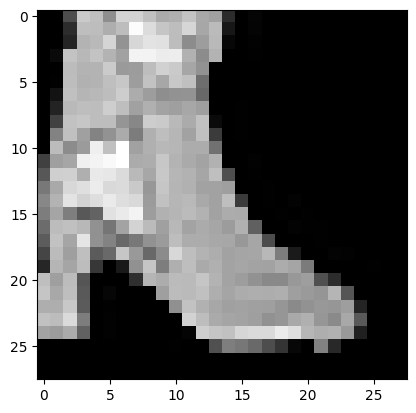

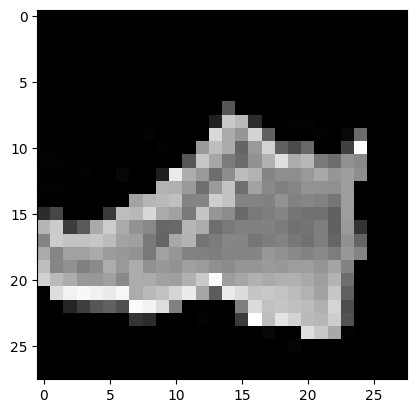

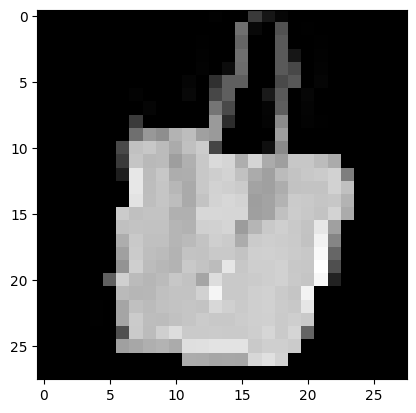

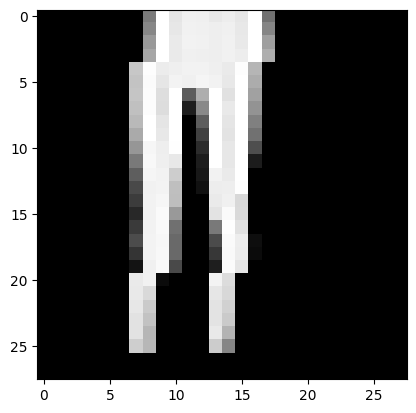

In [6]:
# Посмотрим на аугментированные картинки
images, labels = next(iter(train_loader))

for i in range(9):
    
    img = images[i].numpy().squeeze()
    img = img * std + mean
    img = np.clip(img, 0, 1) 
    
    plt.imshow(img, cmap='gray')
    plt.show()

* Заметим,что не происходит обрезания картинок, поэтому надобности в добавлении паддинга перед применением аугментации нету

## Создадим класс EarlyStoping

In [7]:
# Класс, предназначенный для предотвращения переобучения с сохранением параметров системы
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint4.pth'):
        self.patience = patience    
        self.verbose = verbose      
        self.counter = 0           
        self.best_score = None      
        self.early_stop = False     
        self.val_loss_min = np.inf  
        self.delta = delta          
        self.path = path           

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

## Функция обучения

In [8]:
def train(model, optimizer, epochs=10):

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad(): 
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        train_loss_avg = train_loss / len(train_loader)
        train_acc_avg = train_correct / train_total
        val_loss_avg = val_loss / len(val_loader)
        val_acc_avg = val_correct / val_total
        
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc_avg)
        history['val_acc'].append(val_acc_avg)

        early_stopping(val_loss_avg,model)
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
        clear_output(wait=True)
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f'Epoch {epoch+1} Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history['train_acc'], label='Train Acc')
        plt.plot(history['val_acc'], label='Val Acc')
        plt.title(f'Epoch {epoch+1} Accuracy')
        plt.legend()
        
        plt.show()
        print(f"Epoch {epoch+1}: Train Loss {train_loss_avg:.4f}, Val Acc {val_acc_avg:.4f}, Val Loss {val_loss_avg:.4f}, Train Acc {train_acc_avg:.4f}")

## Создаём архитектуру ResNet

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock,self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels) 
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) 
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, stride=1):
        super(ResNet,self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32,kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()

        self.layer1 = ResidualBlock(32,32)
        self.layer2 = ResidualBlock(32,64, stride=2)  # 14*14*64

        self.fc = nn.Linear(64*14*14,10)
        self.flatten = nn.Flatten()

    def forward(self,x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.flatten(out)
        projection = self.fc(out)
        return projection

In [10]:
model = ResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001,weight_decay=1e-5)
summary(model, input_size=(BATCH_SIZE,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [128, 10]                 --
├─Conv2d: 1-1                            [128, 32, 28, 28]         320
├─BatchNorm2d: 1-2                       [128, 32, 28, 28]         64
├─ReLU: 1-3                              [128, 32, 28, 28]         --
├─ResidualBlock: 1-4                     [128, 32, 28, 28]         --
│    └─Conv2d: 2-1                       [128, 32, 28, 28]         9,248
│    └─BatchNorm2d: 2-2                  [128, 32, 28, 28]         64
│    └─ReLU: 2-3                         [128, 32, 28, 28]         --
│    └─Conv2d: 2-4                       [128, 32, 28, 28]         9,248
│    └─BatchNorm2d: 2-5                  [128, 32, 28, 28]         64
│    └─Sequential: 2-6                   [128, 32, 28, 28]         --
│    └─ReLU: 2-7                         [128, 32, 28, 28]         --
├─ResidualBlock: 1-5                     [128, 64, 14, 14]         --
│    └─C

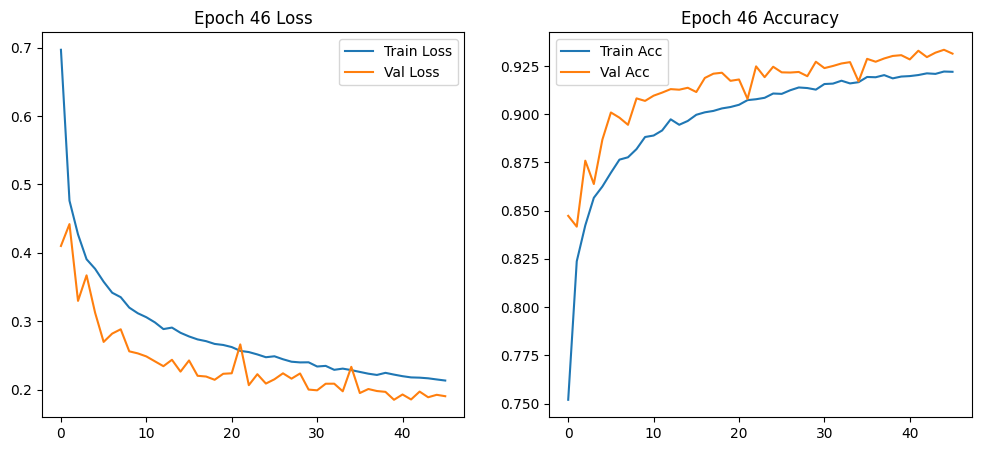

Epoch 46: Train Loss 0.2135, Val Acc 0.9314, Val Loss 0.1906, Train Acc 0.9220
Early stopping


In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stopping = EarlyStopping(patience=7,verbose=True,delta=0.001)
train(model,optimizer,epochs=60)

## Посмотрим на метрики для задач классификации

In [13]:
model.load_state_dict(torch.load('checkpoint4.pth')) # Загружаем параметры модели, сохраненные EarlyStopiing
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"Test Precision (macro): {precision_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Test Recall (macro): {recall_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Test F1 (macro): {f1_score(all_labels, all_preds, average='macro'):.4f}")

Test Accuracy: 0.9274
Test Precision (macro): 0.9271
Test Recall (macro): 0.9274
Test F1 (macro): 0.9270


## Результаты использования Аугментаций и Сверточной сети (ResNet):
* Внедрение пространственных аугментаций успешно решило проблему переобучения. Кривые потерь на обучающей и валидационной выборках демонстрируют стабильную сходимость без существенного расхождения. Использование механизма `EarlyStopping`  позволило автоматически определить оптимальную длительность обучения и остановить процесс после выхода на плато, предотвращая дальнейшее переобучение.

* Модель продемонстрировала высокую эффективность. Помимо Accuracy, модель показала сбалансированные значения макро-метрик: Precision (0.9271), Recall (0.9274) и F1-score (0.9270). Это подтверждает, что модель одинаково хорошо распознает все классы датасета FashionMNIST без смещения предсказаний.

* Переход к архитектуре типа ResNet с использованием остаточных блоков вместо базовой CNN позволил улучшить прохождение градиентов и обеспечить более стабильное обучение. Сочетание такой архитектуры с аугментацией данных позволило получить надежную модель, которая устойчива к реальным искажениям входных изображений.